In [147]:
import kagglehub

# Specify the full Kaggle 'dataset' or 'competition' identifier
comp_id = "playground-series-s5e8"
path = kagglehub.competition_download(comp_id)

print("Downloaded to:", path)

Downloaded to: C:\Users\Youss\.cache\kagglehub\competitions\playground-series-s5e8


In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

train_path = os.path.join(path, "train.csv")
test_path = os.path.join(path, "test.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(train.head(), test.head())

   id  age          job  marital  education default  balance housing loan  \
0   0   42   technician  married  secondary      no        7      no   no   
1   1   38  blue-collar  married  secondary      no      514      no   no   
2   2   36  blue-collar  married  secondary      no      602     yes   no   
3   3   27      student   single  secondary      no       34     yes   no   
4   4   26   technician  married  secondary      no      889     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome  y  
0  cellular   25   aug       117         3     -1         0  unknown  0  
1   unknown   18   jun       185         1     -1         0  unknown  0  
2   unknown   14   may       111         2     -1         0  unknown  0  
3   unknown   28   may        10         2     -1         0  unknown  0  
4  cellular    3   feb       902         1     -1         0  unknown  1          id  age            job  marital  education default  balance housing  \
0  750000   32 

In [149]:
X_train = train.drop(columns = ['y','id'])
y_train = train['y']

### Info

In [150]:
print(X_train.info())
print('-'*25)
print(X_train.describe())
print('-'*25)
print(X_train.describe(include='object'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  duration   750000 non-null  int64 
 12  campaign   750000 non-null  int64 
 13  pdays      750000 non-null  int64 
 14  previous   750000 non-null  int64 
 15  poutcome   750000 non-null  object
dtypes: int64(7), object(9)
memory usage: 91.6+ MB
None
-------------------------
                 age        balance            day       duration  \
count  750000.0000

In [151]:
print(f"duplicates:{X_train.duplicated().sum()}")

duplicates:0


### EDA

#### Numerical Data

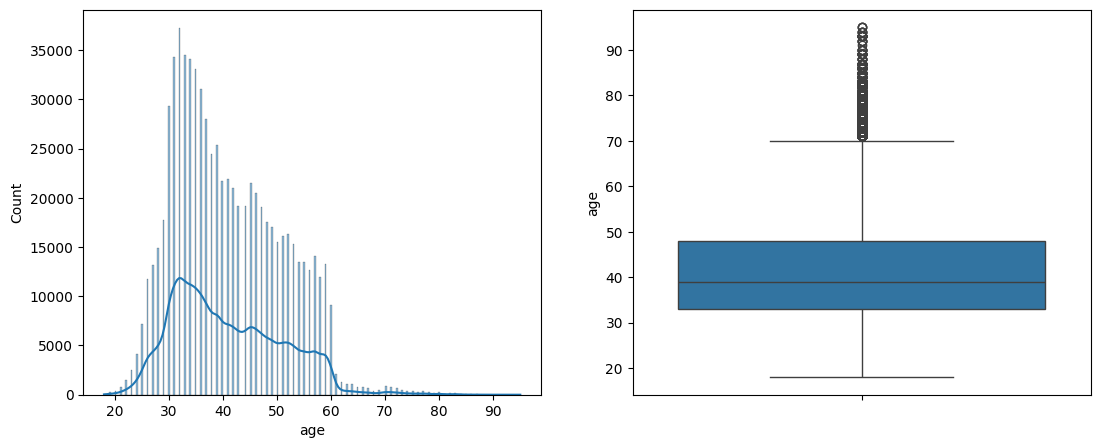

mean:40.92639466666667, median:39.0, mode:32


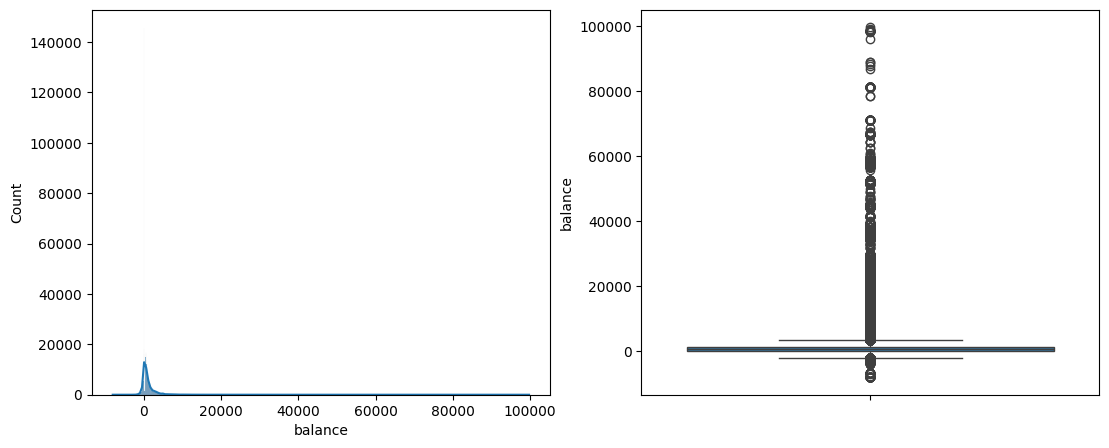

mean:1204.0673973333332, median:634.0, mode:0


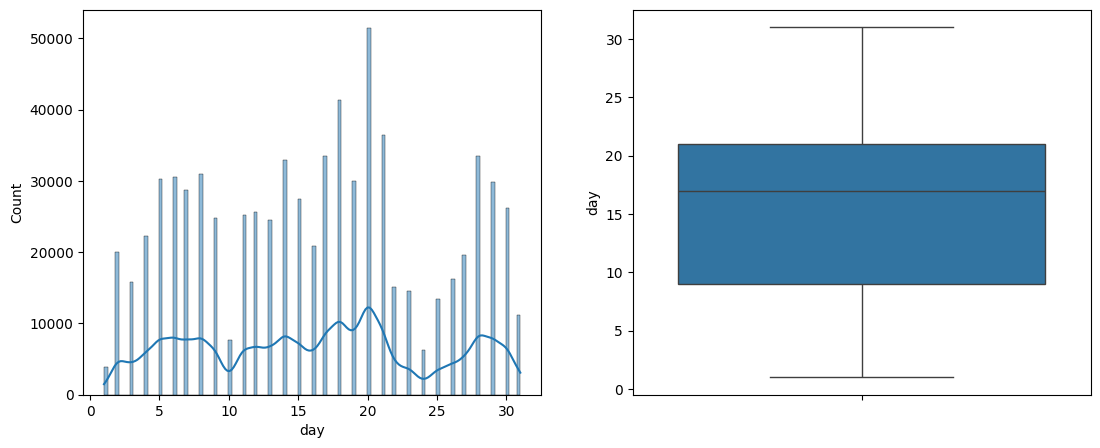

mean:16.117209333333335, median:17.0, mode:20


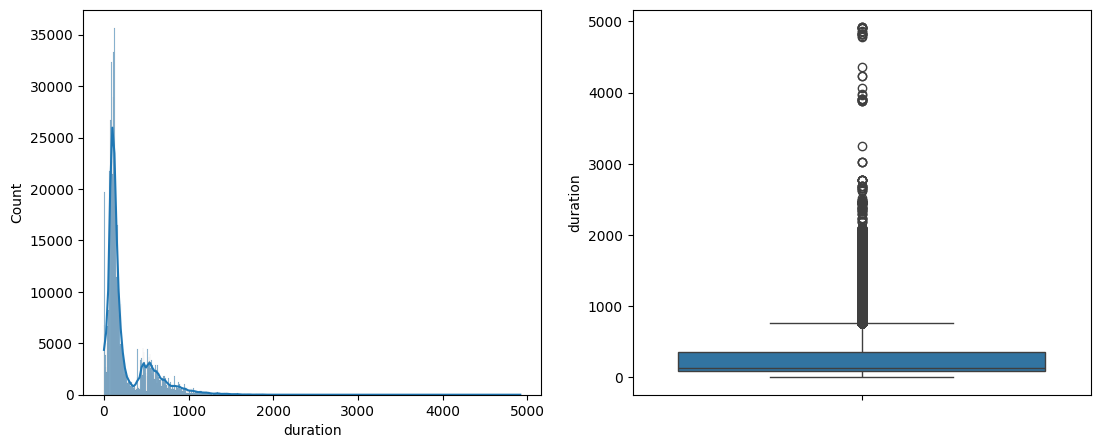

mean:256.229144, median:133.0, mode:124


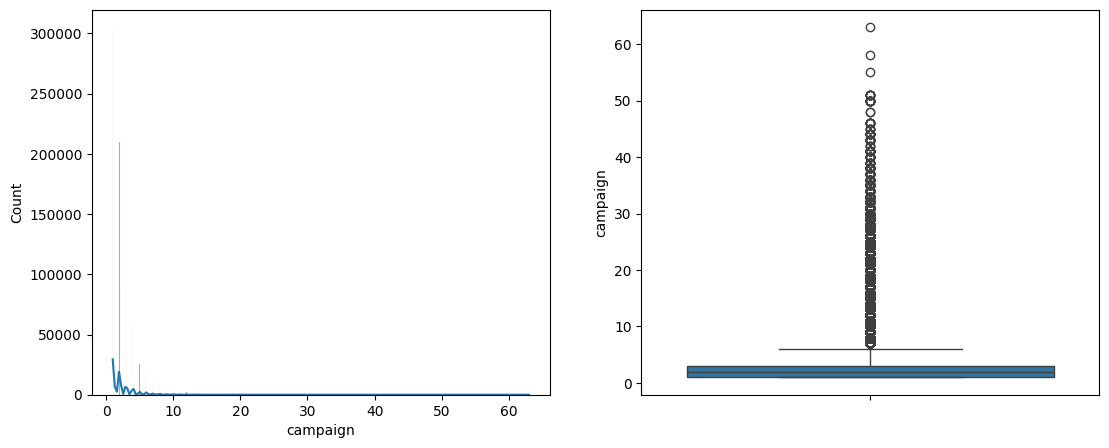

mean:2.577008, median:2.0, mode:1


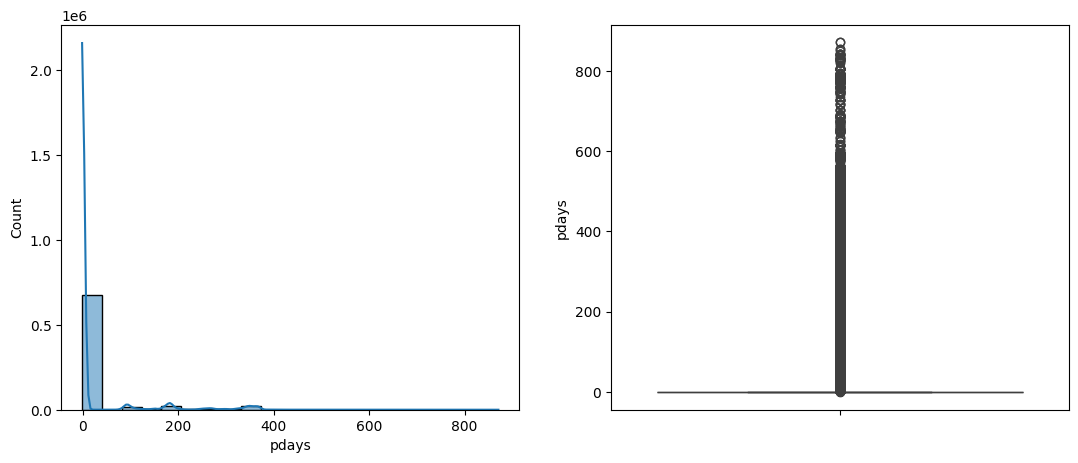

mean:22.412733333333332, median:-1.0, mode:-1


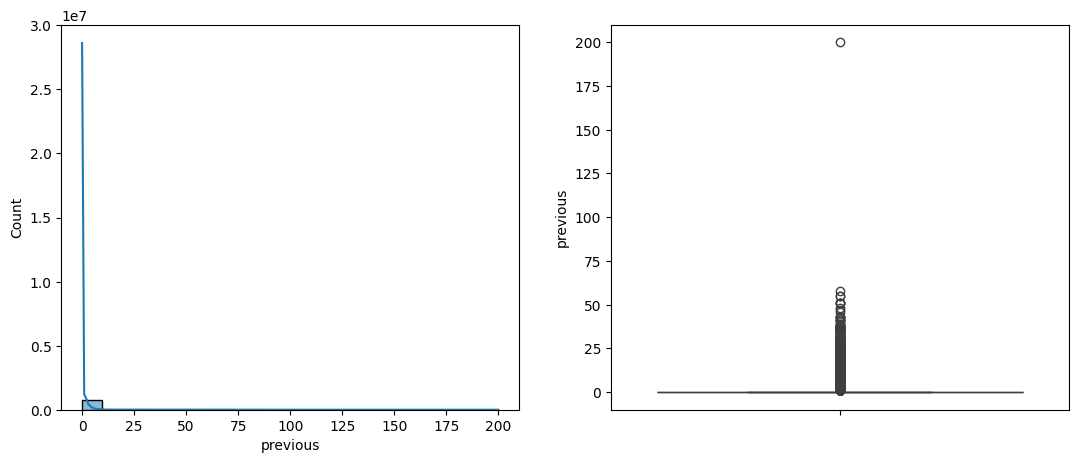

mean:0.29854533333333333, median:0.0, mode:0


In [152]:
numerical_data = X_train.select_dtypes(include=['float64','int64'])
for i in numerical_data:
    plt.figure(figsize=(13,5))
    plt.subplot(1,2,1)
    sns.histplot(data=numerical_data,x=i,kde=True)
    plt.subplot(1,2,2)
    sns.boxplot(data=numerical_data,y=i)
    plt.show()
    print(f'mean:{numerical_data[i].mean()}, median:{numerical_data[i].median()}, mode:{numerical_data[i].mode()[0]}')

conclusion: 
- age, balance, duration -> right skewed
- day -> normal
- campaign, pdays, previous -> right skewed but weird values

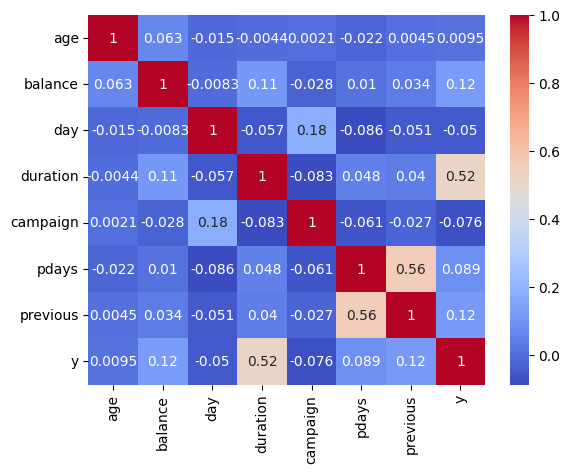

In [153]:
combined = pd.concat([numerical_data, y_train], axis=1)
corr = combined.corr()
sns.heatmap(data=corr,cmap='coolwarm',annot = True)
plt.show()

conclusion:
- there's no high correlation between data and each other and target(y)
- duration and target(y) are the highest correlated
- no correlation too hight to be considered for removal

#### Categorical Data

In [154]:
categorical_data = X_train.select_dtypes(include='object')

for c in categorical_data.columns:
    print(f"{c}:\n {categorical_data[c].unique()}, nunique: {categorical_data[c].nunique()}")
    print(categorical_data[c].value_counts())
    print("-" * 40)

job:
 ['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed'], nunique: 12
job
management       175541
blue-collar      170498
technician       138107
admin.            81492
services          64209
retired           35185
self-employed     19020
entrepreneur      17718
unemployed        17634
housemaid         15912
student           11767
unknown            2917
Name: count, dtype: int64
----------------------------------------
marital:
 ['married' 'single' 'divorced'], nunique: 3
marital
married     480759
single      194834
divorced     74407
Name: count, dtype: int64
----------------------------------------
education:
 ['secondary' 'primary' 'tertiary' 'unknown'], nunique: 4
education
secondary    401683
tertiary     227508
primary       99510
unknown       21299
Name: count, dtype: int64
----------------------------------------
default:
 ['no' 'yes'], nunique: 2
default
no     737151
yes 

conclusion: job, education, contact, poutcome have unknowns and need to be replaced.

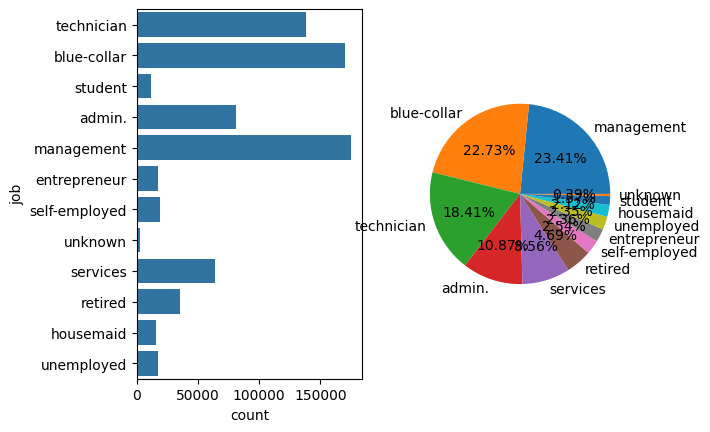

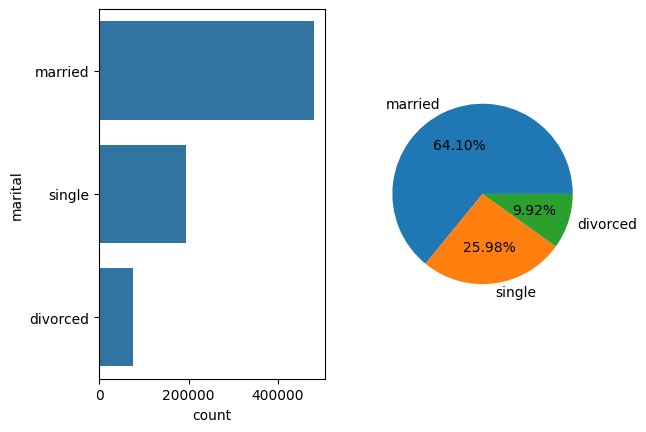

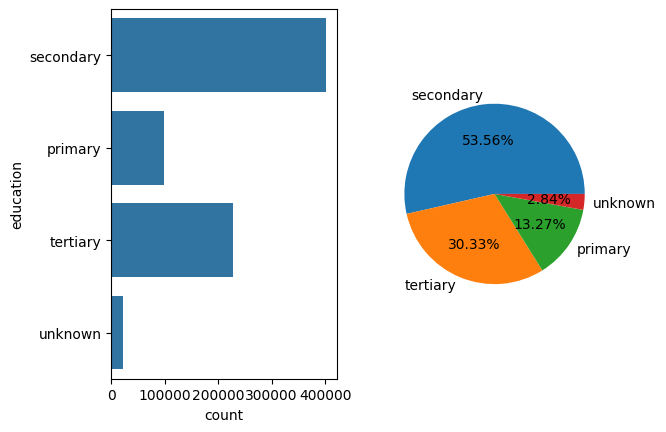

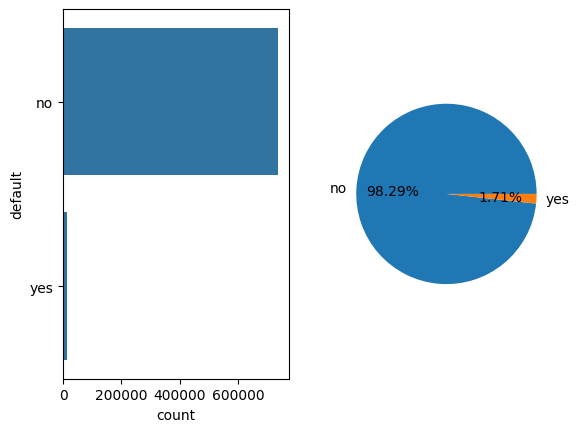

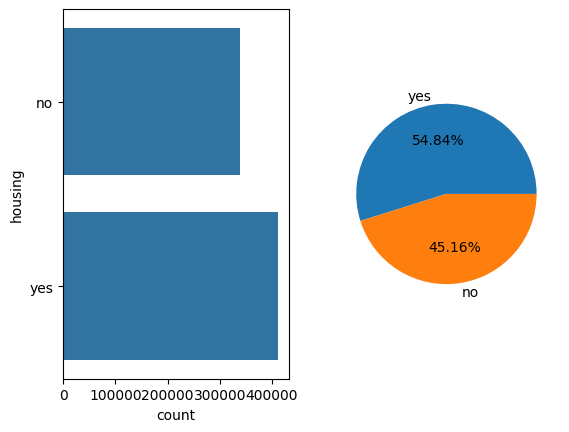

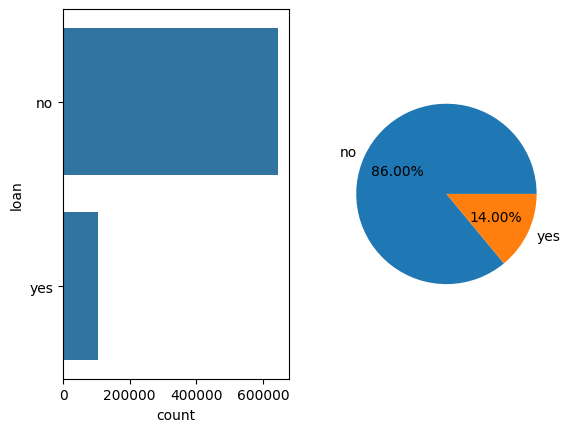

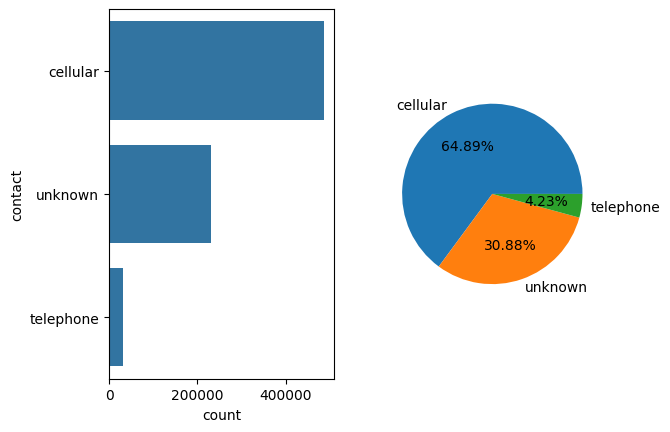

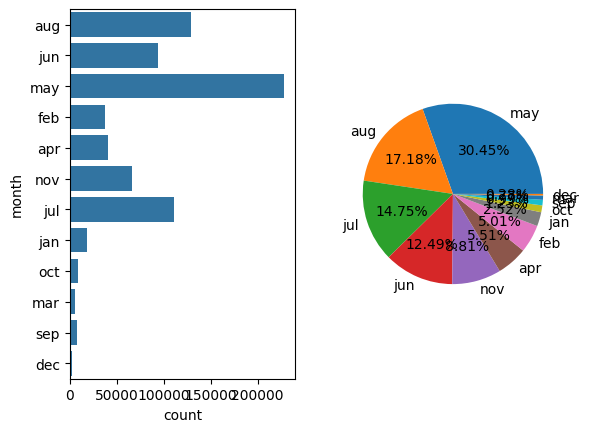

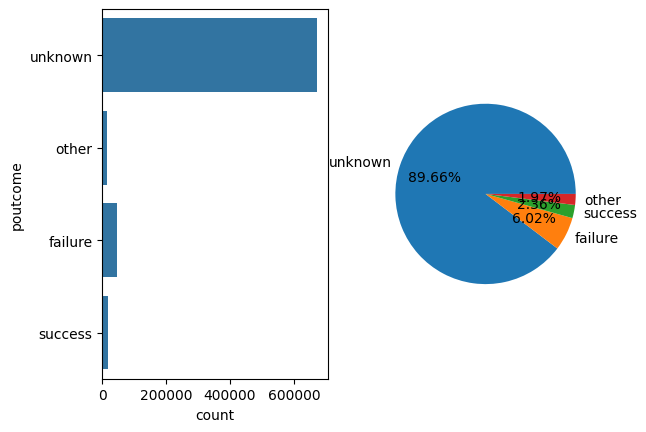

In [155]:
for c in categorical_data:
    plt.subplot(1,2,1)
    sns.countplot(data=categorical_data , y=c)

    plt.subplot(1,2,2)
    val = categorical_data[c].value_counts()
    plt.pie(val.values,labels=val.index,autopct='%1.2f%%')

    plt.show()

unknown percent : solution
- job -> 0.38% (mod)
- education -> 2.84% (mod)
- contact -> 30% (knn imputation)
- poutcome -> 89% (drop)

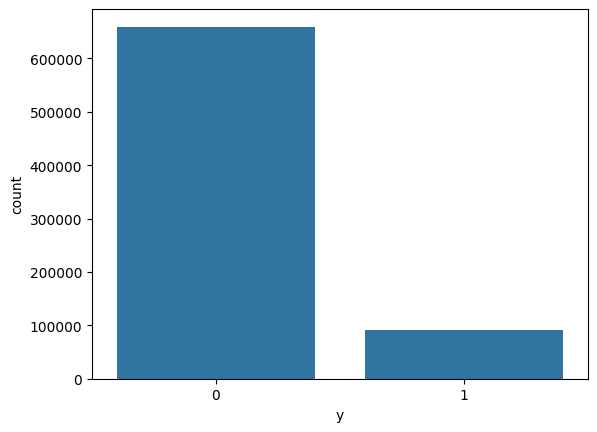

y
0    0.879349
1    0.120651
Name: proportion, dtype: float64


In [156]:
sns.countplot(x=y_train)
plt.show()

print(y_train.value_counts(normalize = True))

conclusion: highly imbalanced target value y

### Preprocessing

Steps:

- drop: pdays, previous, poutcome
- robust scaler: age, balance, duration, campaign
- standard scaler: day
- unknowns: mod/imputation

In [157]:
drop_cols = ['pdays','previous','poutcome']
robust_cols = ['age','balance','duration','campaign']
standard_cols = ['day']
#Encoding
one_hot_cols = categorical_data.drop(columns = ['education','poutcome']).columns
ordinal_cols = ['education']

In [158]:
X_train = X_train.drop(columns = drop_cols)
X_test = test.drop(columns = drop_cols+['id'])

handling unknown

In [159]:
cat_cols = X_train.select_dtypes(include='object').columns
X_train[cat_cols] = X_train[cat_cols].replace('unknown', np.nan)
X_test[cat_cols] = X_test[cat_cols].replace('unknown', np.nan)

In [160]:
from sklearn.impute import SimpleImputer

simple = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = simple.fit_transform(X_train[cat_cols])
X_test[cat_cols] = simple.transform(X_test[cat_cols])

encoding

In [161]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

# one hot
one_hot_encoder = OneHotEncoder(drop='first')
one_hot_array = one_hot_encoder.fit_transform(X_train[one_hot_cols]).toarray()
one_hot_df = pd.DataFrame(one_hot_array, columns=one_hot_encoder.get_feature_names_out(),index=X_train.index)
X_train = X_train.drop(columns=one_hot_cols).join(one_hot_df)

one_hot_array_test = one_hot_encoder.transform(X_test[one_hot_cols]).toarray()
one_hot_df_test = pd.DataFrame(one_hot_array_test,columns=one_hot_encoder.get_feature_names_out(),index=test.index)
X_test = X_test.drop(columns=one_hot_cols).join(one_hot_df_test)

# ordinal
education_order = ['primary','secondary','tertiary']

encoder_ord = OrdinalEncoder(categories=[education_order])
df_encoded = encoder_ord.fit_transform(X_train[ordinal_cols])
X_train[ordinal_cols] = df_encoded 

X_test[ordinal_cols] = encoder_ord.transform(X_test[ordinal_cols])

over sampling (SMOTE)

In [162]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# X_train,y_train = smote.fit_resample(X_train,y_train)
# print(y_train.value_counts())

In [163]:
print(X_train.shape)

(750000, 33)


scaling

In [164]:
from sklearn.preprocessing import RobustScaler,StandardScaler

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

robust = RobustScaler()
X_train_scaled[robust_cols] = robust.fit_transform(X_train[robust_cols])
X_test_scaled[robust_cols] = robust.transform(X_test[robust_cols])

standard = StandardScaler()
X_train_scaled[standard_cols] = standard.fit_transform(X_train[standard_cols])
X_test_scaled[standard_cols] = standard.transform(X_test[standard_cols])

### Feature Selection

In [165]:
from sklearn.feature_selection import chi2

numerical_cols = robust_cols + standard_cols
categorical_X_train = X_train_scaled.drop(columns=numerical_cols)
chi2_scores,p_values = chi2(categorical_X_train,y_train)

chi2_results = pd.DataFrame({
    'Feature': categorical_X_train.columns,
    'Chi2 Score': chi2_scores,
    'p-value': p_values
})
selected_features = chi2_results[chi2_results['p-value'] < 0.05]['Feature']
selected_features = list(selected_features) + numerical_cols

X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f"Before: {X_train_scaled.shape},{X_test_scaled.shape}")
print(f"After: {X_train_selected.shape},{X_test_selected.shape}")


Before: (750000, 33),(250000, 33)
After: (750000, 32),(250000, 32)


In [166]:
from sklearn.feature_selection import f_classif

numerical_X_train = X_train_scaled[numerical_cols]
F_values,p_values = f_classif(numerical_X_train,y_train)

anova_results = pd.DataFrame({
    'Feature': numerical_X_train.columns,
    'F_value': F_values,
    'p-value': p_values
})
print(len(anova_results[anova_results['p-value'] < 0.05]))
print(len(numerical_cols))

5
5


conclusion: all columns are important

In [167]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.97,random_state=42)
X_train_pca = pca.fit_transform(X_train_selected,y_train)
X_test_pca = pca.transform(X_test_selected)

print(f"Before: {X_train.shape},{X_test.shape}")
print(f"After: {X_train_pca.shape},{X_test_pca.shape}")

Before: (750000, 33),(250000, 33)
After: (750000, 17),(250000, 17)


### Modeling

In [168]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve,accuracy_score
def evaluate(y,y_pred,y_pred_prob):
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    print("Classification Report:")
    report = classification_report(y, y_pred,output_dict=True)
    print(classification_report(y, y_pred))

    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    fpr, tpr, _ = roc_curve(y, y_pred_prob)
    plt.figure(figsize=(3,3))
    plt.plot(fpr, tpr, marker='.')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.show()

    auc_score = roc_auc_score(y, y_pred_prob)
    print(f"AUC Score: {auc_score:.2f}")
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]
    return (accuracy,precision,recall,f1,auc_score)

In [169]:
def train_test_eval(model,X_train,y_train):
    model.fit(X_train,y_train)

    y_train_hat = model.predict(X_train)

    y_train_hat_prob = model.predict_proba(X_train)[:,1]

    print("TRAIN:")
    eval = evaluate(y_train,y_train_hat,y_train_hat_prob)

    return model,eval

In [170]:
from sklearn.ensemble import RandomForestClassifier,StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [227]:
rand_forest = RandomForestClassifier(n_estimators=150,criterion='entropy',max_features='sqrt',min_samples_split=5,min_samples_leaf=2,random_state=42,n_jobs=-1)

In [228]:
# from sklearn.model_selection import RandomizedSearchCV

# param_dist = {
#     'min_samples_split': [15, 20, 30, 40, 50],
#     'min_samples_leaf': [10, 15, 20, 30]
# }

# rand_search = RandomizedSearchCV(
#     estimator=rand_forest,
#     param_distributions=param_dist,
#     n_iter=5,            
#     cv=3,
#     scoring='f1',
#     n_jobs=-1,
#     random_state=42,
#     verbose=2
# )

TRAIN:


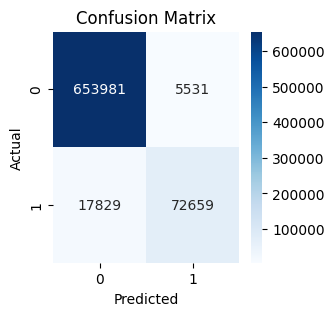

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    659512
           1       0.93      0.80      0.86     90488

    accuracy                           0.97    750000
   macro avg       0.95      0.90      0.92    750000
weighted avg       0.97      0.97      0.97    750000

Accuracy: 0.97


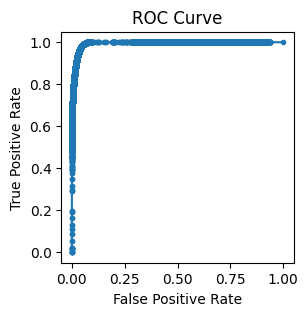

AUC Score: 0.99


In [229]:
model,eval = train_test_eval(rand_forest,X_train,y_train)

### Submission

In [230]:
y_hat = model.predict_proba(X_test)[:,1]
submission = pd.DataFrame({
    'id': test['id'],
    'y': y_hat
})
submission.to_csv("submission.csv", index=False)